In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

N_MELS = 128
MAX_FRAMES = 300      
NUM_CLASSES = 4


In [2]:
meta = pd.read_csv("metadata_features_logmel.csv")
meta.head()


,feature_path,emotion,split
0,features_logmel\train\0.npy,happy,train
1,features_logmel\train\1.npy,sad,train
2,features_logmel\train\2.npy,neutral,train
3,features_logmel\train\3.npy,sad,train
4,features_logmel\train\4.npy,happy,train


In [3]:
le = LabelEncoder()
meta["label_idx"] = le.fit_transform(meta["emotion"])
print("Classes:", list(le.classes_))


Classes: ['angry', 'happy', 'neutral', 'sad']


In [4]:
train_meta = meta[meta["split"] == "train"].reset_index(drop=True)
val_meta   = meta[meta["split"] == "val"].reset_index(drop=True)
test_meta  = meta[meta["split"] == "test"].reset_index(drop=True)

len(train_meta), len(val_meta), len(test_meta)


(8511, 1824, 1824)

In [5]:
def load_features(df):
    X = []
    y = []
    for _, row in df.iterrows():
        feat = np.load(row["feature_path"])       # shape (128, T)
        feat = feat[:, :MAX_FRAMES]
        if feat.shape[1] < MAX_FRAMES:
            pad = MAX_FRAMES - feat.shape[1]
            feat = np.pad(feat, ((0,0),(0,pad)), mode='constant')
        feat = feat[..., np.newaxis]             # (128, T, 1)
        X.append(feat)
        y.append(row["label_idx"])
    return np.array(X, dtype="float32"), np.array(y, dtype="int64")

X_train, y_train = load_features(train_meta)
X_val,   y_val   = load_features(val_meta)
X_test,  y_test  = load_features(test_meta)

X_train.shape, y_train.shape


((8511, 128, 300, 1), (8511,))

In [6]:
def build_cnn_gru_model(input_shape=(N_MELS, MAX_FRAMES, 1), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Permute((2, 1, 3))(x)  # (batch, time, freq, channels)
    B, T, F, C = x.shape
    x = layers.Reshape((T, F * C))(x)  # (batch, time, features)

    x = layers.Bidirectional(layers.GRU(128, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_cnn_gru_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 300, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 300, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 300, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 150, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 150, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 150, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 75, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 75, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 37, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute (Permute)                    │ (None, 37, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 37, 2048)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │       1,672,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,782,980 (6.80 MB)

 Trainable params: 1,782,532 (6.80 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "best_cnn_gru_ser.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

earlystop_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
)


Epoch 1/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.3440 - loss: 1.4019
Epoch 1: val_accuracy improved from -inf to 0.27906, saving model to best_cnn_gru_ser.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 130s 468ms/step - accuracy: 0.3441 - loss: 1.4015 - val_accuracy: 0.2791 - val_loss: 1.3859 - learning_rate: 0.0010
Epoch 2/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.4359 - loss: 1.1855
Epoch 2: val_accuracy improved from 0.27906 to 0.29441, saving model to best_cnn_gru_ser.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 123s 460ms/step - accuracy: 0.4359 - loss: 1.1855 - val_accuracy: 0.2944 - val_loss: 1.3590 - learning_rate: 0.0010
Epoch 3/40
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.4690 - loss: 1.1549
Epoch 3: val_accuracy improved from 0.29441 to 0.41667, saving model to best_cnn_gru_ser.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 142s 461ms/step - accuracy: 0.4690 - loss: 1.1548 - val_accuracy: 0.4167 - val_loss: 1.1890 - learning_rate: 0.0010
Epoch 4/40
266/266 

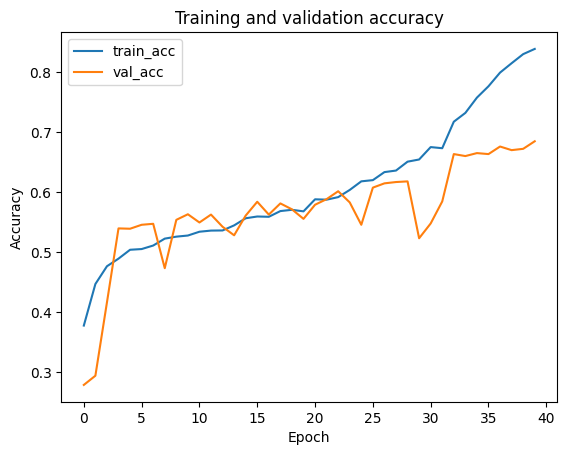

In [8]:
plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.show()


In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.6780 - loss: 0.9553
Test accuracy: 0.6737938523292542


57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step
              precision    recall  f1-score   support

       angry       0.82      0.64      0.72       414
       happy       0.57      0.65      0.61       494
     neutral       0.63      0.72      0.67       505
         sad       0.77      0.68      0.72       411

    accuracy                           0.67      1824
   macro avg       0.70      0.67      0.68      1824
weighted avg       0.69      0.67      0.68      1824



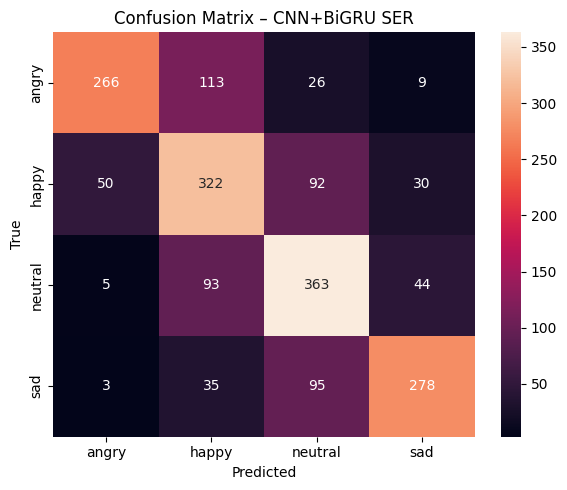

In [10]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_labels,
    target_names=le.classes_
))

cm = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – CNN+BiGRU SER")
plt.tight_layout()
plt.show()
